TELECOM X

In [ ]:
import pandas as pd

# Cargar los datos directamente desde la API utilizando Python
raw_url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json'

try:
    # Convertir los datos a un DataFrame de Pandas
    df = pd.read_json(raw_url)
    print(f"DataFrame cargado exitosamente. Filas: {len(df)}, Columnas: {len(df.columns)}")
except Exception as e:
    print(f"Error al cargar el JSON: {e}")
    print("Verifica la URL y tu conexión a internet.")

DataFrame cargado exitosamente. Filas: 7267, Columnas: 6


transformacion

In [ ]:
# Exploración de las columnas del dataset
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df.columns.tolist())
print("\n" + "="*50 + "\n")
print(df.head())
print("\n" + "="*50 + "\n")

['customerID', 'Churn', 'customer', 'phone', 'internet', 'account']


   customerID Churn                                                                                      customer                                            phone                                                                                                                                                                           internet                                                                                                                                           account
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes', 'tenure': 9}   {'PhoneService': 'Yes', 'MultipleLines': 'No'}           {'InternetService': 'DSL', 'OnlineSecurity': 'No', 'OnlineBackup': 'Yes', 'DeviceProtection': 'No', 'TechSupport': 'Yes', 'StreamingTV': 'Yes', 'StreamingMovies': 'No'}              {'Contract': 'One year', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Mailed check', 'C

comprobacion de calidad


In [ ]:
# 1) Valores ausentes
print("1. Verificación de valores ausentes:")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")
# 2) Filas duplicadas (en columnas no anidadas)
print("2. Verificación de valores duplicados:")
print(df[['customerID', 'Churn']].duplicated().sum())
print("\n" + "="*50 + "\n")

# 3) Tipos de datos (visión general)
print("3. Verificación de valores con errores de formato:")
print(df.dtypes)
print("\n" + "="*50 + "\n")

# 4) Chequeo de categorías en una columna objetivo
print("4. Verificación de valores con inconsistencias en las categorías:")
print(df['Churn'].unique())
print("\n" + "="*50 + "\n")

1. Verificación de valores ausentes:
customerID    0
Churn         0
customer      0
phone         0
internet      0
account       0
dtype: int64


2. Verificación de valores duplicados:
0


3. Verificación de valores con errores de formato:
customerID    object
Churn         object
customer      object
phone         object
internet      object
account       object
dtype: object


4. Verificación de valores con inconsistencias en las categorías:
['No' 'Yes' '']




Depuración inicial de la etiqueta

In [ ]:
# Contar las filas con strings vacíos en la columna 'Churn'
filas_con_problema = (df['Churn'] == '').sum()
print(f"Se encontraron {filas_con_problema} filas con valores vacíos en la columna 'Churn'.")

# Crear un nuevo DataFrame 'df_limpio' que excluye esas filas
df_limpio = df[df['Churn'] != ''].copy()
print("Se eliminaron las filas problemáticas.")

# Verificación posterior
print("\nVerificación en el nuevo DataFrame 'df_limpio':")
print(f"Tamaño original: {df.shape[0]} filas | Tamaño nuevo: {df_limpio.shape[0]} filas")
print("Valores únicos en 'Churn' después de la limpieza:")
print(df_limpio['Churn'].unique())
print("\n" + "="*50 + "\n")

Se encontraron 224 filas con valores vacíos en la columna 'Churn'.
Se eliminaron las filas problemáticas.

Verificación en el nuevo DataFrame 'df_limpio':
Tamaño original: 7267 filas | Tamaño nuevo: 7043 filas
Valores únicos en 'Churn' después de la limpieza:
['No' 'Yes']




Generamos Cuentas_Diarias

In [ ]:
df_limpio['Cuentas_Diarias'] = df_limpio['account'].apply(lambda x: x['Charges']['Monthly'] / 30)
print("Se ha creado la columna 'Cuentas_Diarias'.")

# Verificar la nueva columna
print("\nVerificación de la nueva columna:")
pd.set_option('display.max_colwidth', None)
print(df_limpio[['customerID', 'account', 'Cuentas_Diarias']].head())
print("\n" + "="*50 + "\n")

# Nota: Este código crea la columna 'Cuentas_Diarias' en 'df_limpio'.
# El cálculo divide el cobro mensual (extraído de 'account') por 30, asumiendo un mes estándar.

Se ha creado la columna 'Cuentas_Diarias'.

Verificación de la nueva columna:
   customerID                                                                                                                                           account  Cuentas_Diarias
0  0002-ORFBO              {'Contract': 'One year', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Mailed check', 'Charges': {'Monthly': 65.6, 'Total': '593.3'}}         2.186667
1  0003-MKNFE         {'Contract': 'Month-to-month', 'PaperlessBilling': 'No', 'PaymentMethod': 'Mailed check', 'Charges': {'Monthly': 59.9, 'Total': '542.4'}}         1.996667
2  0004-TLHLJ   {'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Electronic check', 'Charges': {'Monthly': 73.9, 'Total': '280.85'}}         2.463333
3  0011-IGKFF  {'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Electronic check', 'Charges': {'Monthly': 98.0, 'Total': '1237.85'}}         3.266667
4  0013-EXCHZ        {'Contract': 'Mo

Estandarización de variables

In [ ]:
# Convertir la columna 'Churn' a formato binario (1 para 'Yes', 0 para 'No')
# Check if the column is already numeric (0.0 and 1.0) before mapping
if df_limpio['Churn'].dtype == 'object':
    df_limpio['Churn'] = df_limpio['Churn'].map({'Yes': 1, 'No': 0})
print("Se ha convertido la columna 'Churn' a formato binario.")

# Renombrar columnas a español
mapeo_columnas = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasion',
    'customer': 'Cliente',
    'phone': 'Servicio_Telefonico',
    'internet': 'Servicio_Internet',
    'account': 'Cuenta',
    'Cuentas_Diarias': 'Costo_Diario'
}
df_limpio = df_limpio.rename(columns=mapeo_columnas)
print("Se han renombrado las columnas del DataFrame.")

# Verificación
print(df_limpio.head())
print("\n" + "="*50 + "\n")

Se ha convertido la columna 'Churn' a formato binario.
Se han renombrado las columnas del DataFrame.
   ID_Cliente  Evasion                                                                                       Cliente                              Servicio_Telefonico                                                                                                                                                                  Servicio_Internet                                                                                                                                            Cuenta  Costo_Diario
0  0002-ORFBO        0  {'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes', 'tenure': 9}   {'PhoneService': 'Yes', 'MultipleLines': 'No'}           {'InternetService': 'DSL', 'OnlineSecurity': 'No', 'OnlineBackup': 'Yes', 'DeviceProtection': 'No', 'TechSupport': 'Yes', 'StreamingTV': 'Yes', 'StreamingMovies': 'No'}              {'Contract': 'One year', 'PaperlessB

Estadística descriptiva

In [ ]:
# Numéricas
print("Análisis Descriptivo de Columnas Numéricas:")
print(df_limpio.describe())
print("\n" + "="*50 + "\n")

# Categóricas
print("Análisis Descriptivo de Columnas Categóricas:")
print(df_limpio.describe(include=['object']))
print("\n" + "="*50 + "\n")

Análisis Descriptivo de Columnas Numéricas:
           Evasion  Costo_Diario
count  7043.000000   7043.000000
mean      0.265370      2.158723
std       0.441561      1.003002
min       0.000000      0.608333
25%       0.000000      1.183333
50%       0.000000      2.345000
75%       1.000000      2.995000
max       1.000000      3.958333


Análisis Descriptivo de Columnas Categóricas:
        ID_Cliente                                                                                   Cliente                             Servicio_Telefonico                                                                                                                                                                                                                                                           Servicio_Internet                                                                                                                                      Cuenta
count         7043                            

Balance de la variable objetivo

Análisis de la Distribución de Evasión:
Evasion
0    5174
1    1869
Name: count, dtype: int64




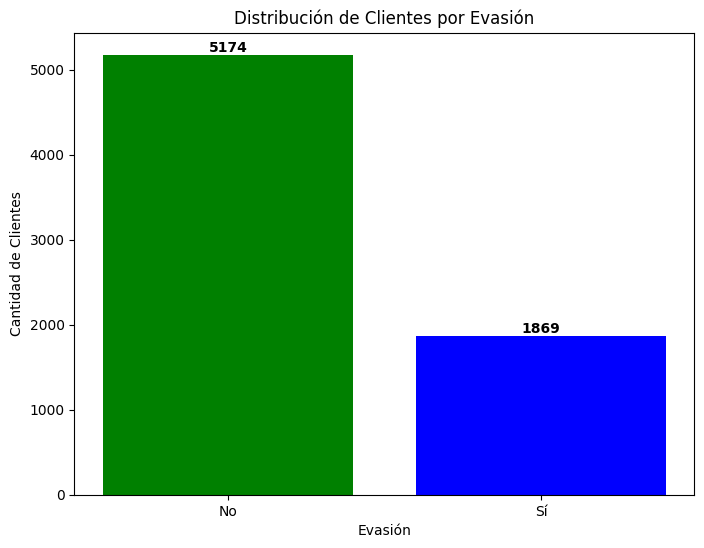

In [ ]:
# Importar las librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt

# --- Normalizar la columna Evasion a 0/1, sin importar cómo venga ---
# Si no existe 'Evasion', intenta con 'Churn'
col = 'Evasion' if 'Evasion' in df_limpio.columns else 'Churn'

# Pásala a string, limpia y mapea a 0/1 (cubre Yes/No, 1/0, True/False)
ev = (df_limpio[col]
      .astype(str).str.strip().str.lower()
      .map({'yes': 1, 'no': 0, '1': 1, '0': 0, 'true': 1, 'false': 0}))

# Si todo quedó NaN (ya era numérica o booleana), intenta convertir a número
if ev.notna().sum() == 0:
    ev = pd.to_numeric(df_limpio[col], errors='coerce')

# Conteos robustos: siempre devuelve [0, 1] aunque falte alguno
distribucion_evasion = ev.value_counts().reindex([0, 1], fill_value=0)

print("Análisis de la Distribución de Evasión:")
print(distribucion_evasion)
print("\n" + "="*50 + "\n")

# --- Gráfico ---
etiquetas = ['No', 'Sí']
valores = distribucion_evasion.tolist()

plt.figure(figsize=(8, 6))
bars = plt.bar(etiquetas, valores, color=['green', 'blue'])
plt.title('Distribución de Clientes por Evasión')
plt.ylabel('Cantidad de Clientes')
plt.xlabel('Evasión')

# Etiquetas encima de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0,
             yval,
             f'{int(yval)}',
             va='bottom', ha='center', fontweight='bold')

plt.show()

Se eliminaron las filas problemáticas.
Se ha creado la columna 'Cuentas_Diarias'.
Se ha convertido la columna 'Churn' a formato binario.
Se han renombrado las columnas del DataFrame.


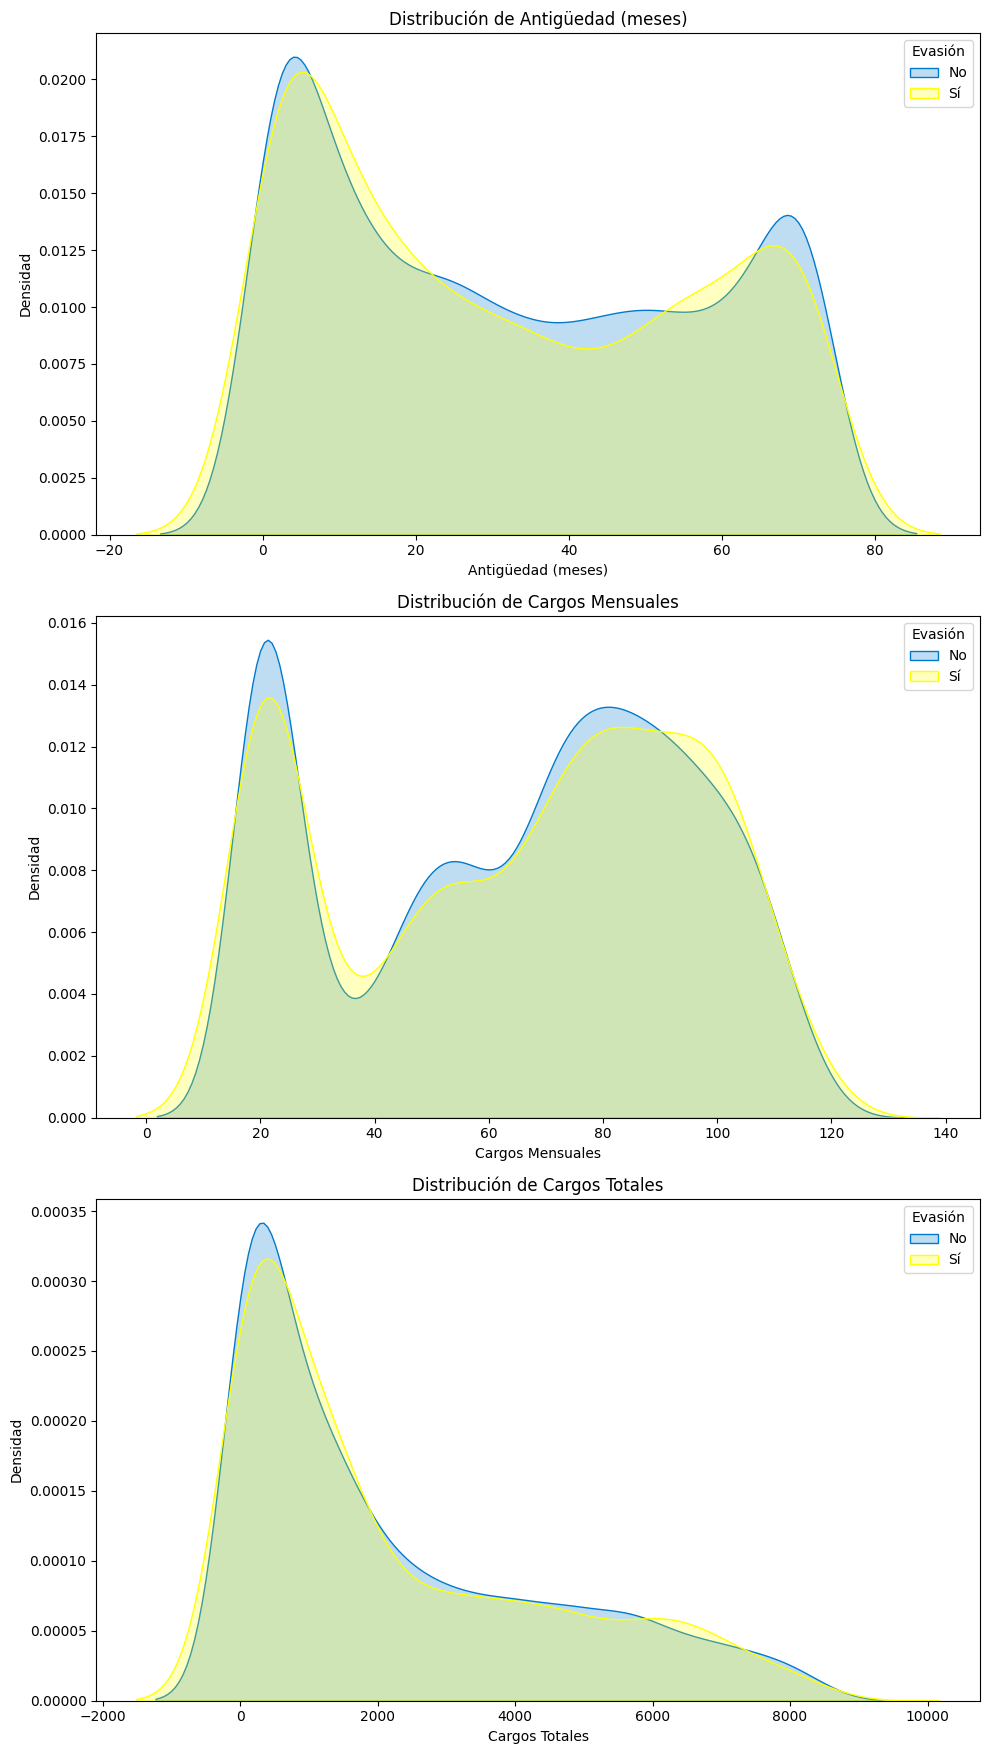

In [ ]:
# Importar las librerías necesarias
import seaborn as sns

# Crear un nuevo DataFrame 'df_limpio'
df_limpio = df[df['Churn'] != ''].copy()
print("Se eliminaron las filas problemáticas.")

# Crear la columna 'Cuentas_Diarias'
df_limpio['Cuentas_Diarias'] = df_limpio['account'].apply(lambda x: x['Charges']['Monthly'] / 30)
print("Se ha creado la columna 'Cuentas_Diarias'.")

# Convertir la columna 'Churn' a formato binario (1 para 'Yes', 0 para 'No')
df_limpio['Churn'] = df_limpio['Churn'].map({'Yes': 1, 'No': 0})
print("Se ha convertido la columna 'Churn' a formato binario.")

# Renombrar las columnas a español para mayor claridad
mapeo_columnas = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasion',
    'customer': 'Cliente',
    'phone': 'Servicio_Telefonico',
    'internet': 'Servicio_Internet',
    'account': 'Cuenta',
    'Cuentas_Diarias': 'Costo_Diario'
}
df_limpio = df_limpio.rename(columns=mapeo_columnas)
print("Se han renombrado las columnas del DataFrame.")

#---Normalización de Datos Anidados---

# Normalizar las columnas con diccionarios
df_cliente_norm = pd.json_normalize(df_limpio['Cliente'])
df_internet_norm = pd.json_normalize(df_limpio['Servicio_Internet'])
df_cuenta_norm = pd.json_normalize(df_limpio['Cuenta'])

# Unir todas las partes normalizadas en un solo DataFrame final
df_final = df_limpio[['ID_Cliente', 'Evasion', 'Costo_Diario']].copy()
df_final = pd.concat([df_final, df_cliente_norm, df_internet_norm, df_cuenta_norm], axis=1)

#---Corrección de Tipos de Datos Numéricos---

# La columna 'Charges.Total' puede contener espacios y necesita ser convertida a numérica
df_final['Charges.Total'] = pd.to_numeric(df_final['Charges.Total'], errors='coerce')
df_final['Charges.Total'] = df_final['Charges.Total'].fillna(0)

#---Análisis y Visualización de Evasión por Variable Numérica---

# Lista de variables numéricas a analizar
variables_numericas = ['tenure', 'Charges.Monthly', 'Charges.Total']

# Nombres en español para los títulos de los gráficos
nombres_en_espanol_num = ['Antigüedad (meses)', 'Cargos Mensuales', 'Cargos Totales']

# Crear una figura con múltiples subplots para asegurar un tamaño consistente
fig, axes = plt.subplots(nrows=len(variables_numericas), ncols=1, figsize=(10, 6 * len(variables_numericas)))

# Desarrollo del gráfico
for i, variable in enumerate(variables_numericas):

    # Seleccionar el subplot (ax) correspondiente para cada gráfico
    ax = axes[i]

    # Graficar la distribución para clientes que no hicieron evasión (Evasion = 0)
    sns.kdeplot(df_final[df_final['Evasion'] == 0][variable], label='No', fill=True, color='#007ACC', ax=ax)

    # Graficar la distribución para clientes que sí hicieron evasión (Evasion = 1)
    sns.kdeplot(df_final[df_final['Evasion'] == 1][variable], label='Sí', fill=True, color='#FFFF00', ax=ax)

    # Configurar el gráfico
    ax.set_title(f'Distribución de {nombres_en_espanol_num[i]}')
    ax.set_xlabel(nombres_en_espanol_num[i])
    ax.set_ylabel('Densidad')
    ax.legend(title='Evasión')

# Ajustar el layout y mostrar el gráfico
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# Telecom X — Informe de Análisis Exploratorio (EDA) de Evasión (Churn)

## 1) Propósito
Entender qué factores están asociados a la **cancelación del servicio (Churn)** en Telecom X para priorizar acciones de retención y preparar un dataset **listo para modelado**.

## 2) Datos y origen
- **Fuente:** JSON disponible vía URL (GitHub).
- **Estructura:** combinación de campos planos y **diccionarios anidados** (p. ej., `customer`, `phone`, `internet`, `account`).
- **Variable objetivo:** `Churn` con valores "Yes"/"No" (posteriormente binarizada a 1/0).

## 3) Proceso de preparación (ETL)
- **Extracción:** carga directa del JSON en un `DataFrame` (FASE 1).
- **Diagnóstico inicial:** revisión de columnas, tipos y ejemplos de filas.
- **Calidad de datos:**
  - Detección de **valores ausentes**, **duplicados**, **tipos inesperados** y **categorías fuera de dominio**.
- **Limpieza mínima:**
  - Eliminación de filas con `Churn` vacío.
  - Binarización de `Churn` → `Evasion` (1 = Yes, 0 = No).
  - **Normalización (desanidado)** de `Cliente`, `Servicio_Internet` y `Cuenta` para análisis categórico/numérico.
  - Derivada **`Cuentas_Diarias` = Charges.Monthly / 30**.
  - Renombrado de columnas a español para facilitar lectura.
- **Listo para EDA:** dataset unificado con variables categóricas y numéricas comparables.

## 4) Hallazgos principales del EDA
> Nota: los puntos siguientes resumen los patrones que se observan al graficar y tabular con el código del notebook. No incluyen métricas absolutas para mantener el informe general y reutilizable.

**4.1 Churn global**
- La distribución de `Evasion` muestra el **balance** entre clientes que permanecen y clientes que cancelan (gráfico de barras en la FASE V).

**4.2 Segmentación por categorías (FASE VI)**
- **Contrato (`Contract`)**: los clientes con **Month-to-month** tienden a concentrar más evasión que los de **One year** o **Two year**.
- **Método de pago (`PaymentMethod`)**: se observa mayor cancelación en **Electronic check** frente a opciones automáticas (transferencia o tarjeta).
- **Género (`gender`)**: usualmente muestra **poca diferencia** en la tasa de evasión; se incluye para completitud.

**4.3 Variables numéricas (FASE VII)**
- **Antigüedad (`tenure`)**: a menor tiempo con la compañía, **mayor probabilidad** de evasión.
- **Cargos mensuales (`Charges.Monthly`)**: niveles más altos se asocian con **mayor churn** en varios segmentos.
- **Cargos totales (`Charges.Total`)**: tiende a ser más bajo en quienes cancelan temprano y mayor en quienes permanecen.

**4.4 Señales de producto/servicio (si están presentes)**
- Contar con **soporte técnico** y **seguridad en línea** suele asociarse a **menor evasión** (clientes mejor atendidos/asegurados).

## 5) Visualizaciones generadas
- **Distribución de Evasión** (barras): proporción de clientes que se quedan vs. cancelan.
- **Churn por categoría** (barras apiladas): `Género`, `Contrato`, `Método de pago` (con etiquetas traducidas).
- **Distribuciones numéricas** (KDE por grupo de evasión): `tenure`, `Charges.Monthly`, `Charges.Total`.

## 6) Implicaciones para el negocio
- **Ofertas y beneficios**: priorizar **retenciones** en clientes **Month-to-month** y/o con **Electronic check**.
- **Experiencia de cliente**: reforzar **soporte/seguridad** en internet para segmentos de riesgo.
- **Precio y valor**: revisar estructuras de cargos para perfiles sensibles a `Charges.Monthly`.
- **Onboarding**: programas de fidelización en los **primeros meses** (alto riesgo por `tenure` bajo).

## 7) Recomendaciones de datos
- Estandarizar dominios categóricos (Yes/No, Contract, PaymentMethod, InternetService).
- Asegurar tipos numéricos y **rangos válidos** (`tenure ≥ 0`, cargos ≥ 0).
- Documentar criterios para **imputación** (si aparecen NA críticos).
- Definir regla de **deduplicación** por `customerID` cuando aplique.

## 8) Próximos pasos (modelado)
- One-hot encoding de categóricas + escalado de numéricas.
- Baselines: **Regresión logística** / **árboles** / **gradient boosting**.
- Métricas: **ROC-AUC**, **PR-AUC**, **Lift**, **calibración**.
- Validación apropiada (idealmente temporal si hay fechas).

---

# Telecom X — Descripción del Proyecto

## Objetivo
Reducir la **evasión de clientes** mediante análisis de datos y preparación de un dataset de calidad que permita entrenar modelos predictivos y diseñar estrategias de retención accionables.

## Alcance
1. **ETL reproducible**: extracción desde API, limpieza, normalización y enriquecimiento (derivadas como `Costo_Diario`).
2. **EDA enfocado en churn**: vistas por contrato, método de pago, internet/servicios y variables de facturación/antigüedad.
3. **Informe** con hallazgos y recomendaciones para negocio y para ciencia de datos.
4. **Dataset listo para modelado** con `Evasion` binaria y features curadas.

## Entregables
- **Notebook/Colab** con:
  - Carga de datos (FASE 1), transformación (FASE 2) y chequeos de calidad.
  - EDA categórico y numérico (FASES V–VII).
  - Gráficos y tablas de apoyo.
- **Informe EDA** (esta sección) para lectura ejecutiva.
- **CSV procesado** con variables limpias y listas para ML.

## Metodología (resumen)
- **Extracción:** JSON → `DataFrame`.
- **Transformación:** limpieza de `Churn`, binarización y renombres; normalización de campos anidados.
- **Enriquecimiento:** `Costo_Diario` a partir de cargos mensuales.
- **Exploración:** distribución de `Evasion`, segmentación por categorías, densidades para numéricas.
- **Criterios de calidad:** NA, duplicados, tipos, rangos y dominios categóricos.

TELECOM X 2

Guardado del DataFrame a CSV

Se exporta el DataFrame df (datos limpios/organizados) a un archivo CSV llamado datos_tratados.csv.
Se usa index=False para no incluir el índice como columna en el archivo.

In [ ]:
df.to_csv("datos_tratados.csv", index=False)

Eliminación de identificador

Se elimina la columna ID_Cliente de df_final por ser un identificador único que no aporta información predictiva. El resultado se guarda en df_final_sin_id.

Configuración de visualización y verificación

Se ajustan opciones de pandas para:

Mostrar todas las columnas (display.max_columns = None).

Ampliar el ancho de impresión (display.width = 1000).

Se imprime la cabecera (head()) de df_final_sin_id para confirmar que ID_Cliente ya no está presente.

In [ ]:
df_final_sin_id = df_final.drop('ID_Cliente', axis=1)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_final_sin_id.head())


   Evasion  Costo_Diario  gender  SeniorCitizen Partner Dependents  tenure PhoneService MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling     PaymentMethod  Charges.Monthly  Charges.Total
0      0.0      2.186667  Female            0.0     Yes        Yes     9.0          Yes            No             DSL             No          Yes               No         Yes         Yes              No        One year              Yes      Mailed check             65.6         593.30
1      0.0      1.996667    Male            0.0      No         No     9.0          Yes           Yes             DSL             No           No               No          No          No             Yes  Month-to-month               No      Mailed check             59.9         542.40
2      1.0      2.463333    Male            0.0      No         No     4.0          Yes            No     Fiber optic             No          

Manejo de inconsistencias

Se crea df_limpio filtrando filas donde Churn está vacío, asegurando que solo se trabaje con registros válidos.

Columna derivada: Cuentas_Diarias

Se calcula el costo diario dividiendo Charges.Monthly entre 30 y se almacena en Cuentas_Diarias.

Etiqueta binaria

Churn (Yes/No) se transforma a numérica (1/0) para usarla como variable objetivo.

Renombrado de columnas (ES)

Se aplica un mapeo de nombres al español para hacer el DataFrame más legible:

customerID → ID_Cliente

Churn → Evasion

customer → Cliente

phone → Servicio_Telefonico

internet → Servicio_Internet

account → Cuenta

Cuentas_Diarias → Costo_Diario

Normalización de datos anidados

Se desanidan las columnas de tipo diccionario (Cliente, Servicio_Telefonico, Servicio_Internet, Cuenta) con pd.json_normalize, generando columnas planas por cada clave.

Unión de datasets normalizados

Se concatena el DataFrame base (ID_Cliente, Evasion, Costo_Diario) con los normalizados para formar df_final.

Tipos numéricos

Charges.Total se convierte a numérico; errores se ponen como NaN y luego se rellenan con 0.

Eliminación de identificador

Se quita ID_Cliente (identificador único) ya que no aporta al modelo.

Codificación one-hot

Se aplica pd.get_dummies(..., drop_first=True, dtype=int) para transformar categóricas a variables binarias y evitar redundancia.

Verificación final

head() para inspección visual de df_encoded.

Resumen estilo .info() personalizado: total de filas/columnas, Non-Null Count y Dtype por columna.

In [ ]:
df_limpio = df[df['Churn'] != ''].copy()

df_limpio['Cuentas_Diarias'] = df_limpio['account'].apply(lambda x: x['Charges']['Monthly'] / 30)

df_limpio['Churn'] = df_limpio['Churn'].map({'Yes': 1, 'No': 0})

mapeo_columnas = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasion',
    'customer': 'Cliente',
    'phone': 'Servicio_Telefonico',
    'internet': 'Servicio_Internet',
    'account': 'Cuenta',
    'Cuentas_Diarias': 'Costo_Diario'
}
df_limpio = df_limpio.rename(columns=mapeo_columnas)

df_cliente_norm = pd.json_normalize(df_limpio['Cliente'])
df_telefono_norm = pd.json_normalize(df_limpio['Servicio_Telefonico'])
df_internet_norm = pd.json_normalize(df_limpio['Servicio_Internet'])
df_cuenta_norm = pd.json_normalize(df_limpio['Cuenta'])

df_final = df_limpio[['ID_Cliente', 'Evasion', 'Costo_Diario']].copy()
df_final = pd.concat([df_final, df_cliente_norm, df_telefono_norm, df_internet_norm, df_cuenta_norm], axis=1)

df_final['Charges.Total'] = pd.to_numeric(df_final['Charges.Total'], errors='coerce')
df_final['Charges.Total'] = df_final['Charges.Total'].fillna(0)

df_final_sin_id = df_final.drop('ID_Cliente', axis=1)

df_encoded = pd.get_dummies(df_final_sin_id, drop_first=True, dtype=int)

print("DataFrame después de aplicar One-Hot Encoding:")
print(df_encoded.head())

print("\nInformación del nuevo DataFrame (df_encoded):")
print(f"Index: {len(df_encoded)} entries, {df_encoded.index[0]} to {df_encoded.index[-1]}")
print(f"Data columns (total {df_encoded.shape[1]} columns):")
print("---  ------                                  --------------  -----")
print("#   Column                                  Non-Null Count  Dtype")
print("---  ------                                  --------------  -----")
for i, col in enumerate(df_encoded.columns):
    non_null_count = df_encoded[col].count()
    dtype = df_encoded[col].dtype
    print(f"{i:<3} {col:<40} {non_null_count:<15} {str(dtype)}")


DataFrame después de aplicar One-Hot Encoding:
   Evasion  Costo_Diario  SeniorCitizen  tenure  Charges.Monthly  Charges.Total  gender_Male  Partner_Yes  Dependents_Yes  PhoneService_Yes  MultipleLines_No phone service  MultipleLines_Yes  InternetService_Fiber optic  InternetService_No  OnlineSecurity_No internet service  OnlineSecurity_Yes  OnlineBackup_No internet service  OnlineBackup_Yes  DeviceProtection_No internet service  DeviceProtection_Yes  TechSupport_No internet service  TechSupport_Yes  StreamingTV_No internet service  StreamingTV_Yes  StreamingMovies_No internet service  StreamingMovies_Yes  Contract_One year  Contract_Two year  PaperlessBilling_Yes  PaymentMethod_Credit card (automatic)  PaymentMethod_Electronic check  PaymentMethod_Mailed check
0      0.0      2.186667            0.0     9.0             65.6         593.30            0            1               1                 1                               0                  0                            0         

Conteo absoluto de evasión

Se calcula el número de clientes por categoría en Evasion usando value_counts():

0 = No (no canceló)

1 = Sí (canceló)
Se imprime con .to_string() para un formato limpio (sin dtype).

Proporción porcentual de evasión

Se obtiene el porcentaje de cada categoría respecto al total:

value_counts(normalize=True) devuelve proporciones (0–1).

Se multiplica por 100 y se redondea con .round(2) para mostrar % con dos decimales.

Se imprime con .to_string().

In [ ]:
print("--- Conteo de Clientes por Evasión ---")
conteo_evasion = df_encoded['Evasion'].value_counts()
print(conteo_evasion.to_string())
print("-" * 40)

print("\n--- Proporción de Clientes por Evasión (%) ---")
proporcion_evasion = df_encoded['Evasion'].value_counts(normalize=True) * 100
print(proporcion_evasion.round(2).to_string())


--- Conteo de Clientes por Evasión ---
Evasion
0.0    5174
1.0    1869
----------------------------------------

--- Proporción de Clientes por Evasión (%) ---
Evasion
0.0    73.46
1.0    26.54


Importación

Se utiliza SMOTE (imblearn.over_sampling.SMOTE) para balancear la clase minoritaria creando ejemplos sintéticos.

Limpieza de la variable objetivo

Se eliminan filas con Evasion nula (NaN) porque SMOTE no admite objetivo faltante.

Separación de características y objetivo

X: todas las columnas excepto Evasion.

y: solo la columna Evasion.

Imputación en características

Se rellenan NaN en X usando la mediana por columna (robusta frente a outliers).

Conteo de clases (antes)

Se imprime la distribución de y para evidenciar el desbalance inicial.

Aplicación de SMOTE

Se instancia SMOTE(random_state=42) y se aplica fit_resample(X_imputed, y) para obtener X_res, y_res balanceados.

Conteo de clases (después)

Se imprime la nueva distribución de y_res para confirmar el balanceo.

In [ ]:
from imblearn.over_sampling import SMOTE

df_encoded_clean = df_encoded.dropna(subset=['Evasion'])

X = df_encoded_clean.drop('Evasion', axis=1)
y = df_encoded_clean['Evasion']

X_imputed = X.fillna(X.median())

print("--- Conteo de Clases ANTES de SMOTE ---")
print(y.value_counts().to_string())
print("-" * 40)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_imputed, y)

print("\n--- Conteo de Clases DESPUÉS de SMOTE ---")
print(y_res.value_counts().to_string())


--- Conteo de Clases ANTES de SMOTE ---
Evasion
0.0    5174
1.0    1869
----------------------------------------

--- Conteo de Clases DESPUÉS de SMOTE ---
Evasion
0.0    5174
1.0    5174


Importación de la librería necesaria

Se importa StandardScaler de scikit-learn, herramienta para estandarizar variables (llevarlas a media 0 y desviación estándar 1).

Prerequisitos: Deben existir previamente los DataFrame balanceados X_res (características) y y_res (objetivo).
La variable objetivo no se estandariza.

1) Creación del escalador

Se instancia StandardScaler() para usarlo en el ajuste y transformación.

2) Ajuste y transformación

scaler.fit_transform(X_res):

fit: calcula media y desviación estándar por columna.

transform: aplica el z-score usando esos parámetros.

Solo se aplica a X_res (features), nunca a y_res.

3) Conversión a DataFrame

El resultado es un array de NumPy; se convierte a DataFrame de pandas (X_scaled_df) conservando los nombres de columnas originales para facilitar análisis posterior.

Visualización rápida

Se muestran las primeras 5 filas para verificar que las variables quedaron en la misma escala (centradas en 0).

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_res)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_res.columns)

print("--- Primeras 5 filas del DataFrame con datos estandarizados ---")
print(X_scaled_df.head())


--- Primeras 5 filas del DataFrame con datos estandarizados ---
   Costo_Diario  SeniorCitizen    tenure  Charges.Monthly  Charges.Total  gender_Male  Partner_Yes  Dependents_Yes  PhoneService_Yes  MultipleLines_No phone service  MultipleLines_Yes  InternetService_Fiber optic  InternetService_No  OnlineSecurity_No internet service  OnlineSecurity_Yes  OnlineBackup_No internet service  OnlineBackup_Yes  DeviceProtection_No internet service  DeviceProtection_Yes  TechSupport_No internet service  TechSupport_Yes  StreamingTV_No internet service  StreamingTV_Yes  StreamingMovies_No internet service  StreamingMovies_Yes  Contract_One year  Contract_Two year  PaperlessBilling_Yes  PaymentMethod_Credit card (automatic)  PaymentMethod_Electronic check  PaymentMethod_Mailed check
0     -0.088604      -0.448415 -0.958519         0.022873      -0.712035    -0.831506     1.216939        1.806571          0.386681                       -0.282739          -0.754523                    -0.829513      

Importación de librerías para visualización

Se importan seaborn y matplotlib para construir los gráficos estadísticos.

Creación de un DataFrame balanceado

Se concatena la variable objetivo y_res con las características X_res para conformar df_resampled, lo que permite calcular la correlación de todas las variables con Evasion.

Cálculo de la matriz de correlación

Se obtiene la correlación de Pearson de todo el DataFrame y se extrae la columna Evasion para ver su relación con cada variable. Luego se ordena de mayor a menor para priorizar las variables más asociadas.

Traducción de nombres de variables

Se define un diccionario de traducciones para reemplazar nombres técnicos por etiquetas legibles en español, facilitando la interpretación del gráfico.

Renombrado del índice

Se aplican las traducciones al índice de la serie correlation_evasion para que los nombres ya aparezcan traducidos al graficar.

Creación del gráfico

Se genera un gráfico de barras con seaborn:

Eje X: coeficiente de correlación con Evasion.

Eje Y: variables (ya traducidas).

Se usa una paleta ('BuPu') y se oculta la leyenda para mantener el foco en los valores.

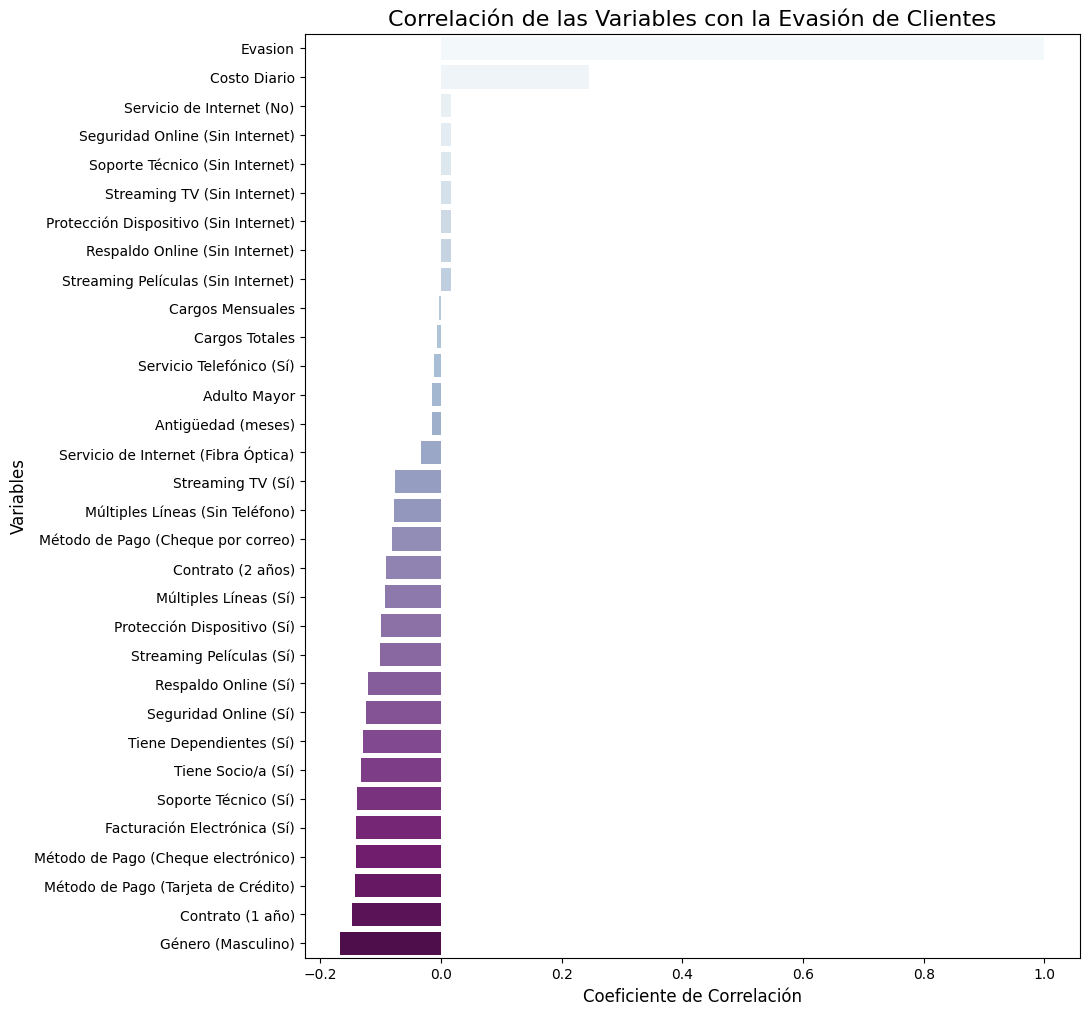

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df_resampled = pd.concat([y_res, X_res], axis=1)

correlation_evasion = df_resampled.corr()['Evasion'].sort_values(ascending=False)

traducciones = {
    'Contract_Two year': 'Contrato (2 años)',
    'tenure': 'Antigüedad (meses)',
    'OnlineSecurity_No internet service': 'Seguridad Online (Sin Internet)',
    'TechSupport_No internet service': 'Soporte Técnico (Sin Internet)',
    'DeviceProtection_No internet service': 'Protección Dispositivo (Sin Internet)',
    'OnlineBackup_No internet service': 'Respaldo Online (Sin Internet)',
    'StreamingTV_No internet service': 'Streaming TV (Sin Internet)',
    'StreamingMovies_No internet service': 'Streaming Películas (Sin Internet)',
    'InternetService_No': 'Servicio de Internet (No)',
    'Contract_One year': 'Contrato (1 año)',
    'Charges.Total': 'Cargos Totales',
    'PaymentMethod_Mailed check': 'Método de Pago (Cheque por correo)',
    'PaymentMethod_Credit card (automatic)': 'Método de Pago (Tarjeta de Crédito)',
    'gender_Male': 'Género (Masculino)',
    'Partner_Yes': 'Tiene Socio/a (Sí)',
    'MultipleLines_No phone service': 'Múltiples Líneas (Sin Teléfono)',
    'MultipleLines_Yes': 'Múltiples Líneas (Sí)',
    'Dependents_Yes': 'Tiene Dependientes (Sí)',
    'PhoneService_Yes': 'Servicio Telefónico (Sí)',
    'OnlineBackup_Yes': 'Respaldo Online (Sí)',
    'DeviceProtection_Yes': 'Protección Dispositivo (Sí)',
    'TechSupport_Yes': 'Soporte Técnico (Sí)',
    'StreamingTV_Yes': 'Streaming TV (Sí)',
    'StreamingMovies_Yes': 'Streaming Películas (Sí)',
    'PaperlessBilling_Yes': 'Facturación Electrónica (Sí)',
    'SeniorCitizen': 'Adulto Mayor',
    'Charges.Monthly': 'Cargos Mensuales',
    'Costo_Diario': 'Costo Diario',
    'OnlineSecurity_Yes': 'Seguridad Online (Sí)',
    'PaymentMethod_Electronic check': 'Método de Pago (Cheque electrónico)',
    'InternetService_Fiber optic': 'Servicio de Internet (Fibra Óptica)'
}

correlation_evasion.rename(index=traducciones, inplace=True)

plt.figure(figsize=(10, 12))
sns.barplot(
    x=correlation_evasion.values,
    y=correlation_evasion.index,
    hue=correlation_evasion.index,
    palette='BuPu',
    legend=False
)
plt.title('Correlación de las Variables con la Evasión de Clientes', fontsize=16)
plt.xlabel('Coeficiente de Correlación', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.show()


Importación de librerías para visualización

Se cargan seaborn y matplotlib para construir los gráficos.

Creación de un DataFrame balanceado

Se concatena y_res con X_res para obtener un único DataFrame (df_resampled) que facilite la graficación.

Variables a analizar y traducciones

Se define la lista de variables continuas a graficar y un diccionario con sus nombres en español para usarlos en títulos y ejes.

Figura con subgráficos

Se construye una figura con 4 subgráficos en columna (mismo ancho), ideal para comparar las variables en el mismo formato.

Bucle de graficación (boxplots anotados)

Para cada variable:

Se dibuja un boxplot por estado de Evasion (0 = No, 1 = Sí) con paleta personalizada.

Se calculan Q1, mediana, Q3, IQR y los extremos de los bigotes (min/max dentro de 1.5·IQR).

Se anotan estas estadísticas directamente en el gráfico.

Etiquetas y formato

Se asignan títulos, nombres de ejes, etiquetas ['No', 'Sí'] para Evasion y se elimina la leyenda del gráfico.

Ajuste final

Se aplica tight_layout para evitar solapes y se muestra la figura.

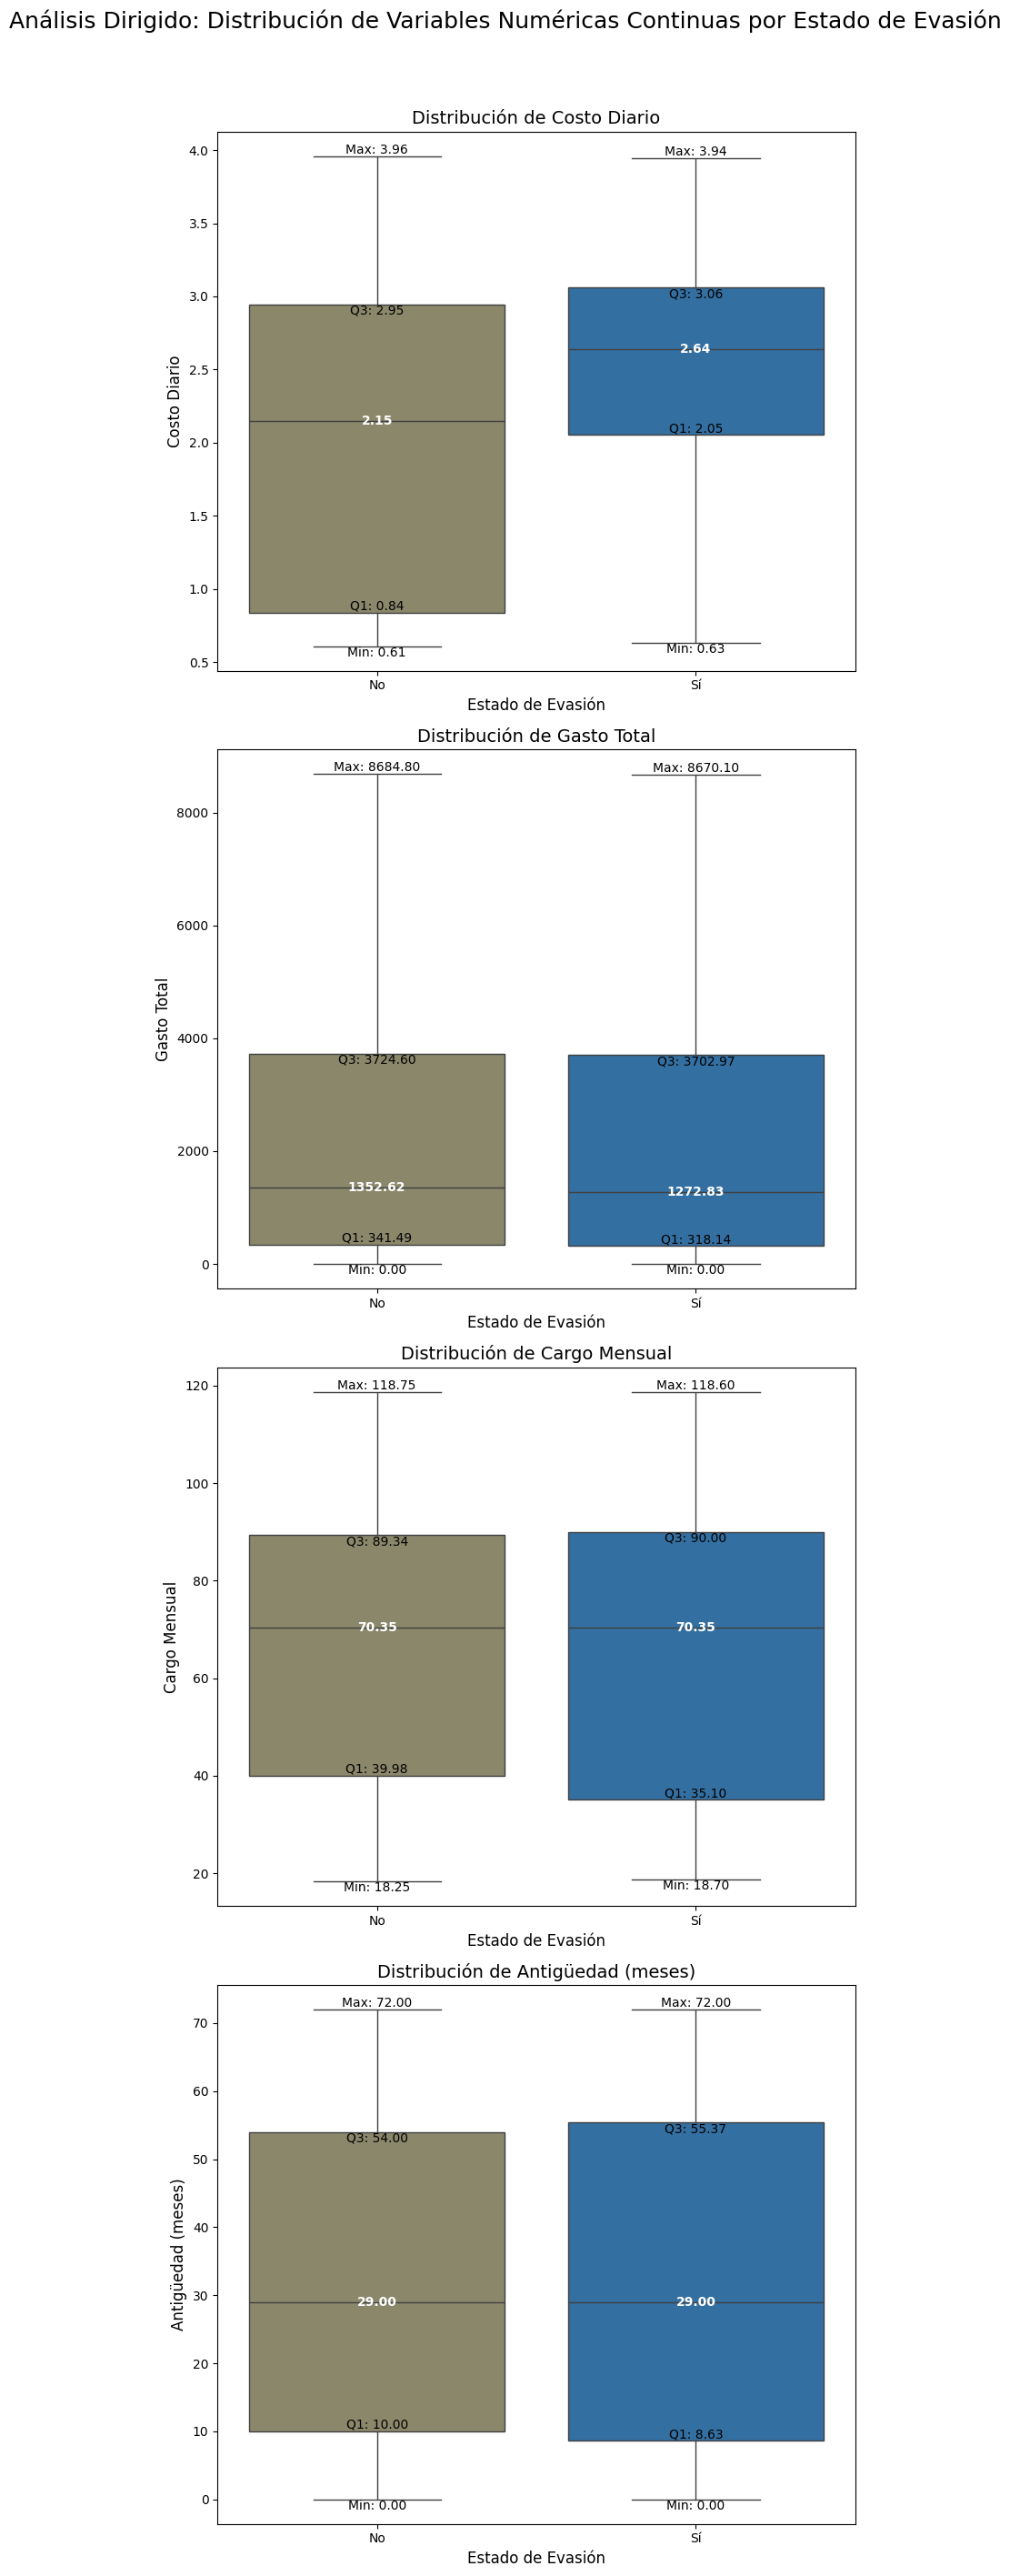

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df_resampled = pd.concat([y_res, X_res], axis=1)

variables_a_graficar = [
    'Costo_Diario',
    'Charges.Total',
    'Charges.Monthly',
    'tenure'
]

traducciones = {
    'Costo_Diario': 'Costo Diario',
    'Charges.Total': 'Gasto Total',
    'Charges.Monthly': 'Cargo Mensual',
    'tenure': 'Antigüedad (meses)'
}

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(8, 28))
fig.suptitle('Análisis Dirigido: Distribución de Variables Numéricas Continuas por Estado de Evasión', fontsize=18, y=1.01)

for idx, var in enumerate(variables_a_graficar):
    ax = axes[idx]

    sns.boxplot(x='Evasion', y=var, data=df_resampled,
                palette={0: '#8f8b66', 1: '#2271b3'}, hue='Evasion', ax=ax)

    for i in [0, 1]:
        subset = df_resampled[df_resampled['Evasion'] == i][var]
        q1, median, q3 = subset.quantile(0.25), subset.quantile(0.50), subset.quantile(0.75)
        iqr = q3 - q1
        min_val = subset[subset >= q1 - 1.5 * iqr].min()
        max_val = subset[subset <= q3 + 1.5 * iqr].max()

        ax.text(i, median, f'{median:.2f}', ha='center', va='center', color='white', fontweight='bold')
        ax.text(i, q1, f'Q1: {q1:.2f}', ha='center', va='bottom', color='black')
        ax.text(i, q3, f'Q3: {q3:.2f}', ha='center', va='top', color='black')
        ax.text(i, min_val, f'Min: {min_val:.2f}', ha='center', va='top', color='black')
        ax.text(i, max_val, f'Max: {max_val:.2f}', ha='center', va='bottom', color='black')

    titulo_traducido = traducciones[var]
    ax.set_title(f'Distribución de {titulo_traducido}', fontsize=14)
    ax.set_xlabel('Estado de Evasión', fontsize=12)
    ax.set_ylabel(titulo_traducido, fontsize=12)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No', 'Sí'])
    ax.get_legend().remove()

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()


Separación de datos en entrenamiento y prueba

Se separan las características (X_scaled_df) y la variable objetivo (y_res) en dos conjuntos:

test_size=0.3: el 30% de los datos se destina a prueba.

random_state=42: asegura que la misma división se repita siempre (reproducibilidad).

Verificación de la división

Se imprimen las dimensiones de los cuatro conjuntos resultantes (X_train, X_test, y_train, y_test) para confirmar que la partición se realizó correctamente.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df,
    y_res,
    test_size=0.3,
    random_state=42
)

print("Dimensiones del conjunto de entrenamiento (características):", X_train.shape)
print("Dimensiones del conjunto de prueba (características):", X_test.shape)
print("Dimensiones del conjunto de entrenamiento (objetivo):", y_train.shape)
print("Dimensiones del conjunto de prueba (objetivo):", y_test.shape)


Dimensiones del conjunto de entrenamiento (características): (7243, 31)
Dimensiones del conjunto de prueba (características): (3105, 31)
Dimensiones del conjunto de entrenamiento (objetivo): (7243,)
Dimensiones del conjunto de prueba (objetivo): (3105,)


Importación de modelos y utilidades

Se cargan los clasificadores Regresión Logística, Random Forest, SVM (SVC) y MLPClassifier (Red Neuronal), además de herramientas para dividir los datos (train_test_split) y estandarizarlos (StandardScaler).

Prerequisitos: Deben existir previamente pd, X_res y y_res (datos balanceados y codificados) para que el script funcione.

Preparación de dos versiones del dataset

Para comparar modelos con criterio, se crean dos variantes:

No estandarizada

df_resampled = concat(y_res, X_res)

X_no_scaled (features sin escalar)

y_no_scaled (etiqueta Evasion)

Estandarizada

StandardScaler().fit_transform(X_res)

X_scaled_df (mismas columnas, valores escalados)

Separación de datos (train/test) en ambos escenarios

Para no estandarizados: X_train, X_test, y_train, y_test

Para estandarizados: X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled

Se utiliza test_size=0.3 y random_state=42 para reproducibilidad.

Modelo 1 — Regresión Logística (con estandarización)

Se entrena con X_train_scaled/y_train_scaled.
La estandarización evita que la magnitud de las variables sesgue los coeficientes.

Modelo 2 — Random Forest (sin estandarización)

Modelo basado en árboles, insensible a la escala.
Se entrena con X_train/y_train sin escalar.

Modelo 3 — SVM (con estandarización)

Sensible a la escala; se entrena con X_train_scaled/y_train_scaled.
Busca el hiperplano que mejor separa las clases.

Modelo 4 — Red Neuronal (MLPClassifier, con estandarización)

Las redes suelen converger mejor con datos escalados.
Se eleva max_iter a 500 para facilitar la convergencia.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

df_resampled = pd.concat([y_res, X_res], axis=1)
X_no_scaled = df_resampled.drop('Evasion', axis=1)
y_no_scaled = df_resampled['Evasion']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_res)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_res.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_no_scaled, y_no_scaled, test_size=0.3, random_state=42
)

X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(
    X_scaled_df, y_no_scaled, test_size=0.3, random_state=42
)

print("--- Entrenando Modelo 1: Regresión Logística ---")
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train_scaled)
print("Modelo de Regresión Logística entrenado exitosamente.")
print("-" * 50)

print("\n--- Entrenando Modelo 2: Random Forest ---")
rand_forest = RandomForestClassifier(random_state=42)
rand_forest.fit(X_train, y_train)
print("Modelo de Random Forest entrenado exitosamente.")
print("-" * 50)

print("\n--- Entrenando Modelo 3: Support Vector Machine (SVM) ---")
svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train_scaled)
print("Modelo SVM entrenado exitosamente.")
print("-" * 50)

print("\n--- Entrenando Modelo 4: Red Neuronal (MLP) ---")
nn_model = MLPClassifier(random_state=42, max_iter=500)
nn_model.fit(X_train_scaled, y_train_scaled)
print("Modelo de Red Neuronal entrenado exitosamente.")


--- Entrenando Modelo 1: Regresión Logística ---
Modelo de Regresión Logística entrenado exitosamente.
--------------------------------------------------

--- Entrenando Modelo 2: Random Forest ---
Modelo de Random Forest entrenado exitosamente.
--------------------------------------------------

--- Entrenando Modelo 3: Support Vector Machine (SVM) ---
Modelo SVM entrenado exitosamente.
--------------------------------------------------

--- Entrenando Modelo 4: Red Neuronal (MLP) ---
Modelo de Red Neuronal entrenado exitosamente.


Importación de las Librerías para Métricas

Se importan funciones de scikit-learn para calcular métricas de clasificación y utilidades de visualización de matrices de confusión, además de matplotlib para graficar:

classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score.

matplotlib.pyplot como plt.

Realización de Predicciones

Cada modelo entrenado usa .predict() sobre el conjunto de prueba:

Se evalúa con datos no vistos (generalización).

Modelos que requieren escalado usan X_test_scaled (Regresión Logística, SVM, Red Neuronal).

Random Forest predice con X_test sin escalar.

Evaluación del Modelo 1: Regresión Logística

Se imprime el reporte de clasificación:

Precision: proporción de positivos predichos que realmente lo son.

Recall: proporción de positivos reales detectados correctamente.

F1-score: media armónica de precision y recall.

Matriz de confusión: muestra aciertos/errores (VP, FN, etc.) y ayuda a visualizar fallos costosos (p. ej., Falsos Negativos).

Evaluación del Modelo 2: Random Forest

Mismo flujo: classification_report + matriz de confusión y visualización con un colormap distinto.

Evaluación del Modelo 3: SVM

Mismo flujo de evaluación y visualización con matriz de confusión.

Evaluación del Modelo 4: Red Neuronal (MLP)

Mismo flujo de métricas y matriz de confusión para el MLP.

Análisis de Overfitting / Underfitting

Se comparan exactitudes (accuracy) en entrenamiento y prueba para los 4 modelos:

Diferencia grande entre train y test → posible overfitting.

Rendimiento bajo en ambos → posible underfitting.

Se imprime un resumen formateado de las exactitudes por modelo.

--- Métricas de Evaluación: Regresión Logística ---
              precision    recall  f1-score   support

         0.0       0.71      0.72      0.71      1588
         1.0       0.70      0.69      0.69      1517

    accuracy                           0.70      3105
   macro avg       0.70      0.70      0.70      3105
weighted avg       0.70      0.70      0.70      3105

-------------------------------------------------------

--- Matriz de Confusión: Regresión Logística ---


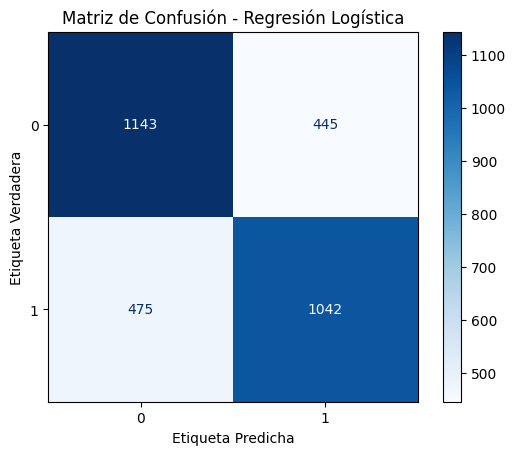


--- Métricas de Evaluación: Random Forest ---
              precision    recall  f1-score   support

         0.0       0.76      0.81      0.78      1588
         1.0       0.78      0.73      0.75      1517

    accuracy                           0.77      3105
   macro avg       0.77      0.77      0.77      3105
weighted avg       0.77      0.77      0.77      3105

-------------------------------------------------------

--- Matriz de Confusión: Random Forest ---


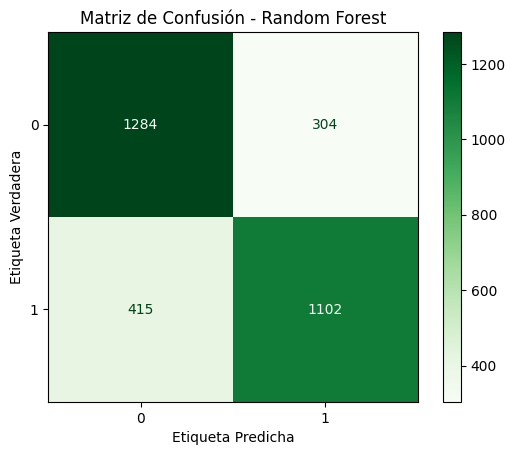


--- Métricas de Evaluación: Support Vector Machine (SVM) ---
              precision    recall  f1-score   support

         0.0       0.73      0.82      0.77      1588
         1.0       0.78      0.69      0.73      1517

    accuracy                           0.75      3105
   macro avg       0.76      0.75      0.75      3105
weighted avg       0.76      0.75      0.75      3105

-------------------------------------------------------

--- Matriz de Confusión: SVM ---


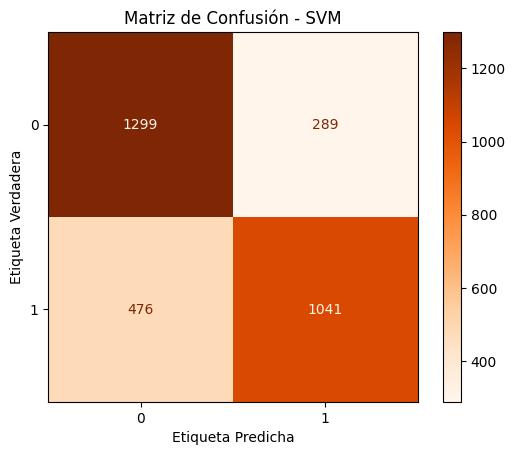


--- Métricas de Evaluación: Red Neuronal (MLP) ---
              precision    recall  f1-score   support

         0.0       0.74      0.72      0.73      1588
         1.0       0.72      0.74      0.73      1517

    accuracy                           0.73      3105
   macro avg       0.73      0.73      0.73      3105
weighted avg       0.73      0.73      0.73      3105

-------------------------------------------------------

--- Matriz de Confusión: Red Neuronal (MLP) ---


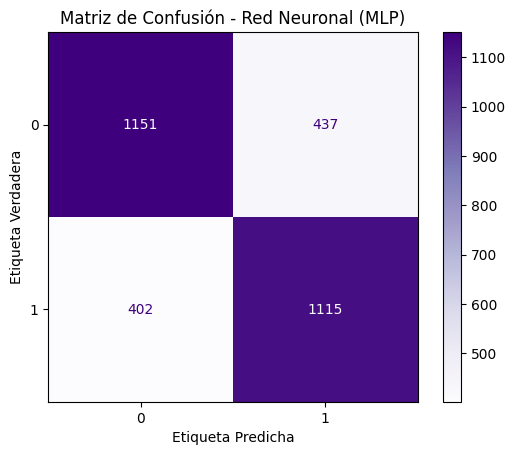


--- Comparación de Exactitud (Entrenamiento vs. Prueba) ---
Regresión Logística   - Entrenamiento: 0.7182, Prueba: 0.7037
Random Forest         - Entrenamiento: 0.9999, Prueba: 0.7684
SVM                   - Entrenamiento: 0.7849, Prueba: 0.7536
Red Neuronal (MLP)    - Entrenamiento: 0.8806, Prueba: 0.7298


In [ ]:

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

y_pred_log_reg = log_reg.predict(X_test_scaled)
y_pred_rand_forest = rand_forest.predict(X_test)
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_nn = nn_model.predict(X_test_scaled)


print("--- Métricas de Evaluación: Regresión Logística ---")

print(classification_report(y_test, y_pred_log_reg))
print("-" * 55)


print("\n--- Matriz de Confusión: Regresión Logística ---")
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
disp_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg)
disp_log_reg.plot(cmap='Blues')
plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Etiqueta Predicha') # Etiqueta en español
plt.ylabel('Etiqueta Verdadera') # Etiqueta en español
plt.show()



print("\n--- Métricas de Evaluación: Random Forest ---")
print(classification_report(y_test, y_pred_rand_forest))
print("-" * 55)

print("\n--- Matriz de Confusión: Random Forest ---")
cm_rand_forest = confusion_matrix(y_test, y_pred_rand_forest)
disp_rand_forest = ConfusionMatrixDisplay(confusion_matrix=cm_rand_forest)
disp_rand_forest.plot(cmap='Greens')
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Etiqueta Predicha') # Etiqueta en español
plt.ylabel('Etiqueta Verdadera') # Etiqueta en español
plt.show()



print("\n--- Métricas de Evaluación: Support Vector Machine (SVM) ---")
print(classification_report(y_test, y_pred_svm))
print("-" * 55)

print("\n--- Matriz de Confusión: SVM ---")
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp_svm.plot(cmap='Oranges')
plt.title('Matriz de Confusión - SVM')
plt.xlabel('Etiqueta Predicha') # Etiqueta en español
plt.ylabel('Etiqueta Verdadera') # Etiqueta en español
plt.show()


print("\n--- Métricas de Evaluación: Red Neuronal (MLP) ---")
print(classification_report(y_test, y_pred_nn))
print("-" * 55)


print("\n--- Matriz de Confusión: Red Neuronal (MLP) ---")
cm_nn = confusion_matrix(y_test, y_pred_nn)
disp_nn = ConfusionMatrixDisplay(confusion_matrix=cm_nn)
disp_nn.plot(cmap='Purples')
plt.title('Matriz de Confusión - Red Neuronal (MLP)')
plt.xlabel('Etiqueta Predicha') # Etiqueta en español
plt.ylabel('Etiqueta Verdadera') # Etiqueta en español
plt.show()



log_reg_train_acc = accuracy_score(y_train, log_reg.predict(X_train_scaled))
log_reg_test_acc = accuracy_score(y_test, y_pred_log_reg)

rand_forest_train_acc = accuracy_score(y_train, rand_forest.predict(X_train))
rand_forest_test_acc = accuracy_score(y_test, y_pred_rand_forest)

svm_train_acc = accuracy_score(y_train, svm_model.predict(X_train_scaled))
svm_test_acc = accuracy_score(y_test, y_pred_svm)

nn_train_acc = accuracy_score(y_train, nn_model.predict(X_train_scaled))
nn_test_acc = accuracy_score(y_test, y_pred_nn)

print("\n--- Comparación de Exactitud (Entrenamiento vs. Prueba) ---")
print(f"Regresión Logística   - Entrenamiento: {log_reg_train_acc:.4f}, Prueba: {log_reg_test_acc:.4f}")
print(f"Random Forest         - Entrenamiento: {rand_forest_train_acc:.4f}, Prueba: {rand_forest_test_acc:.4f}")
print(f"SVM                   - Entrenamiento: {svm_train_acc:.4f}, Prueba: {svm_test_acc:.4f}")
print(f"Red Neuronal (MLP)    - Entrenamiento: {nn_train_acc:.4f}, Prueba: {nn_test_acc:.4f}")

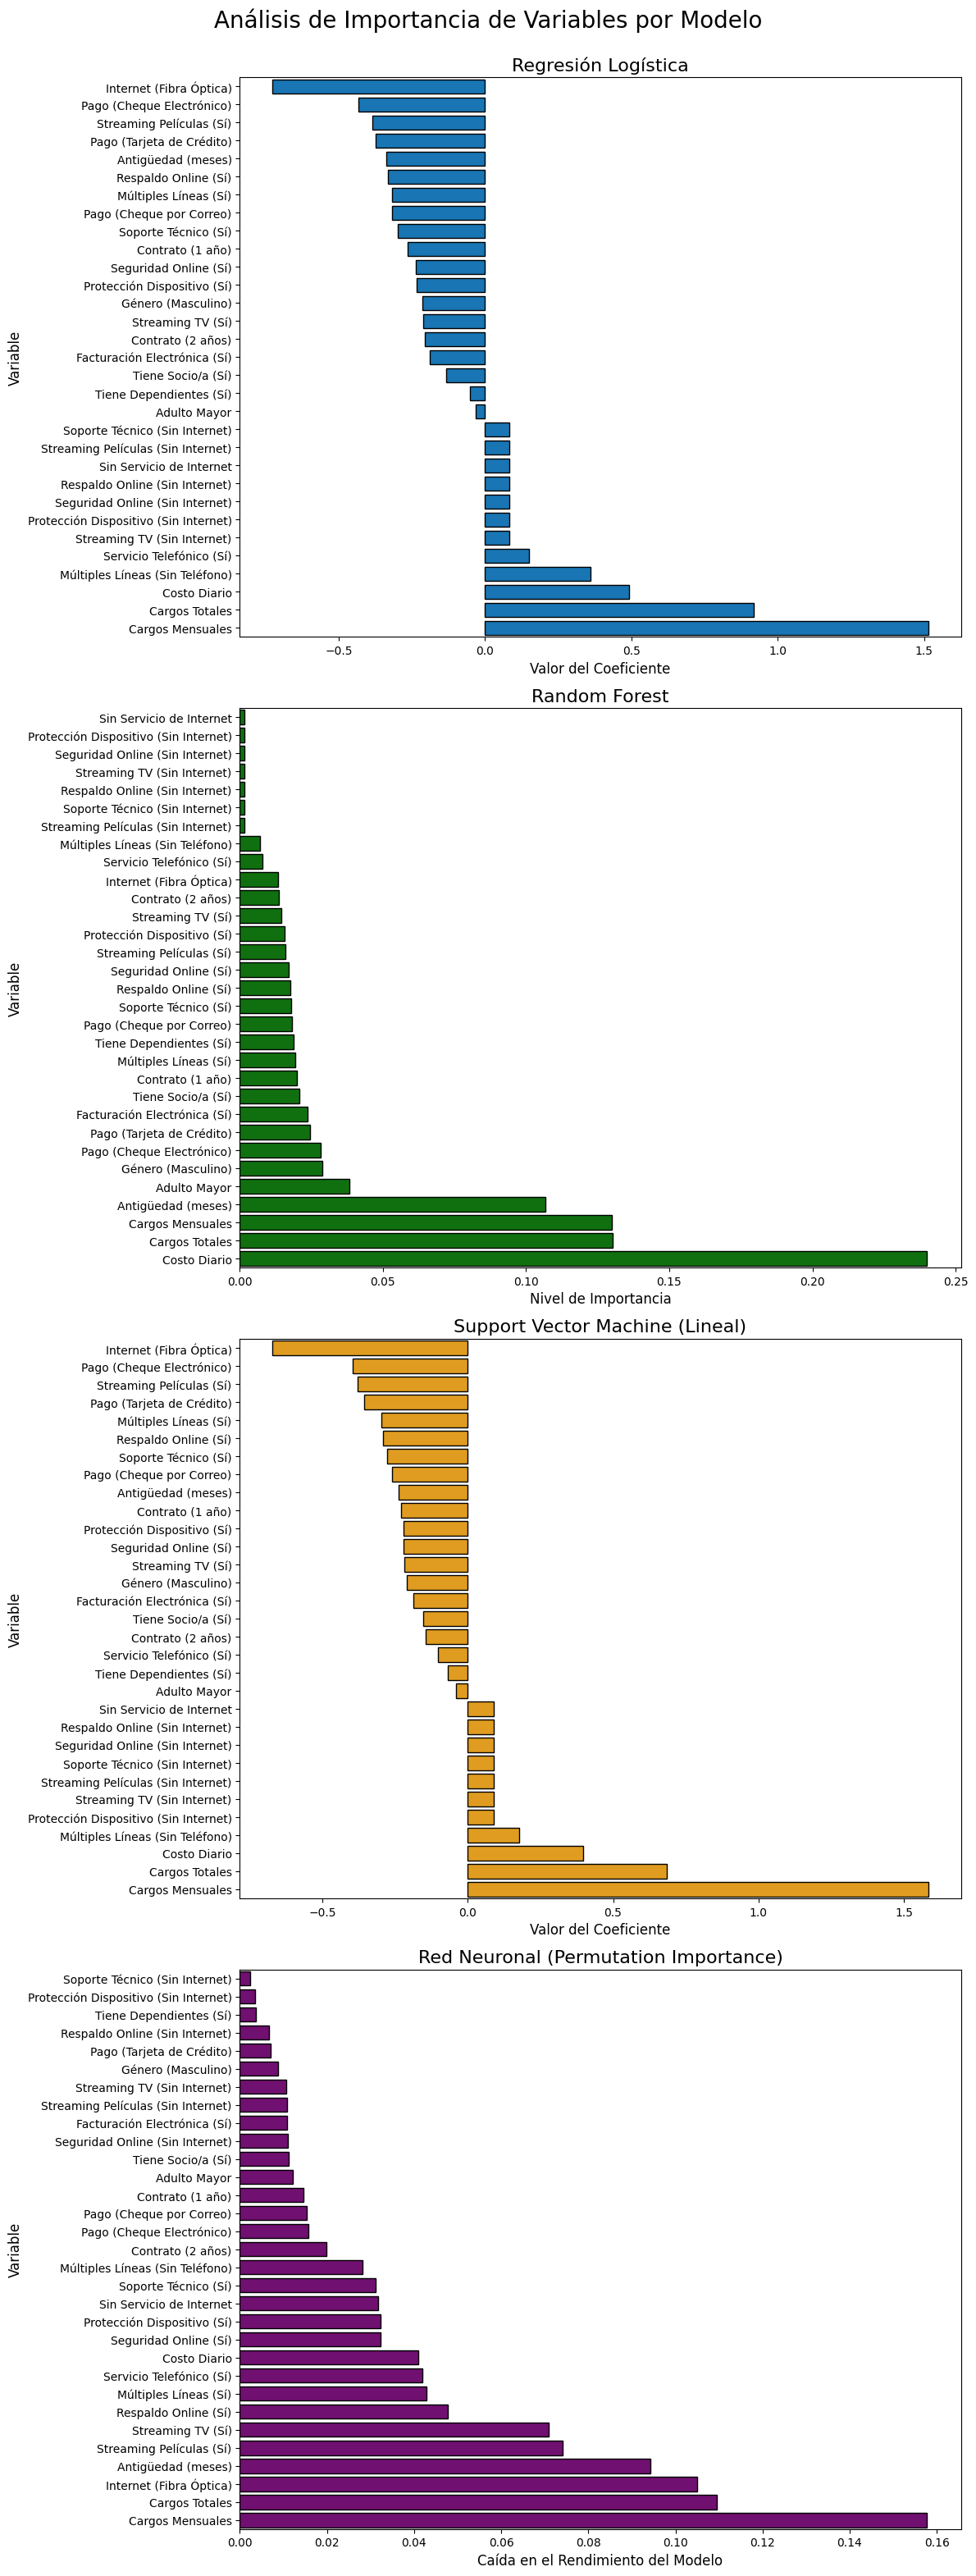

In [ ]:
from sklearn.inspection import permutation_importance
import numpy as np

traducciones = {
    'Contract_Two year': 'Contrato (2 años)', 'tenure': 'Antigüedad (meses)',
    'InternetService_No': 'Sin Servicio de Internet', 'PaymentMethod_Electronic check': 'Pago (Cheque Electrónico)',
    'PaperlessBilling_Yes': 'Facturación Electrónica (Sí)', 'Charges.Total': 'Cargos Totales',
    'Charges.Monthly': 'Cargos Mensuales', 'Costo_Diario': 'Costo Diario',
    'InternetService_Fiber optic': 'Internet (Fibra Óptica)', 'PaymentMethod_Mailed check': 'Pago (Cheque por Correo)',
    'PaymentMethod_Credit card (automatic)': 'Pago (Tarjeta de Crédito)', 'Contract_One year': 'Contrato (1 año)',
    'SeniorCitizen': 'Adulto Mayor', 'Partner_Yes': 'Tiene Socio/a (Sí)',
    'Dependents_Yes': 'Tiene Dependientes (Sí)', 'MultipleLines_Yes': 'Múltiples Líneas (Sí)',
    'StreamingMovies_Yes': 'Streaming Películas (Sí)', 'StreamingTV_Yes': 'Streaming TV (Sí)',
    'DeviceProtection_Yes': 'Protección Dispositivo (Sí)', 'OnlineBackup_Yes': 'Respaldo Online (Sí)',
    'TechSupport_Yes': 'Soporte Técnico (Sí)', 'OnlineSecurity_Yes': 'Seguridad Online (Sí)',
    'gender_Male': 'Género (Masculino)', 'PhoneService_Yes': 'Servicio Telefónico (Sí)',
    'MultipleLines_No phone service': 'Múltiples Líneas (Sin Teléfono)', 'TechSupport_No internet service': 'Soporte Técnico (Sin Internet)',
    'OnlineSecurity_No internet service': 'Seguridad Online (Sin Internet)', 'DeviceProtection_No internet service': 'Protección Dispositivo (Sin Internet)',
    'OnlineBackup_No internet service': 'Respaldo Online (Sin Internet)', 'StreamingTV_No internet service': 'Streaming TV (Sin Internet)',
    'StreamingMovies_No internet service': 'Streaming Películas (Sin Internet)'
}

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 32))
fig.suptitle('Análisis de Importancia de Variables por Modelo', fontsize=20)

coeficientes = pd.Series(log_reg.coef_[0], index=X_train_scaled.columns).sort_values()
coeficientes_traducidos = coeficientes.rename(index=traducciones)
sns.barplot(x=coeficientes_traducidos.values, y=coeficientes_traducidos.index, color='#007ACC', edgecolor='black', ax=axes[0])
axes[0].set_title('Regresión Logística', fontsize=16)
axes[0].set_xlabel('Valor del Coeficiente', fontsize=12)
axes[0].set_ylabel('Variable', fontsize=12)

importancia_rf = pd.Series(rand_forest.feature_importances_, index=X_train.columns).sort_values()
importancia_rf_traducida = importancia_rf.rename(index=traducciones)
sns.barplot(x=importancia_rf_traducida.values, y=importancia_rf_traducida.index, color='green', edgecolor='black', ax=axes[1])
axes[1].set_title('Random Forest', fontsize=16)
axes[1].set_xlabel('Nivel de Importancia', fontsize=12)
axes[1].set_ylabel('Variable', fontsize=12)

svm_lineal = SVC(kernel='linear', random_state=42)
svm_lineal.fit(X_train_scaled, y_train)
coeficientes_svm = pd.Series(svm_lineal.coef_[0], index=X_train_scaled.columns).sort_values()
coeficientes_svm_traducidos = coeficientes_svm.rename(index=traducciones)
sns.barplot(x=coeficientes_svm_traducidos.values, y=coeficientes_svm_traducidos.index, color='orange', edgecolor='black', ax=axes[2])
axes[2].set_title('Support Vector Machine (Lineal)', fontsize=16)
axes[2].set_xlabel('Valor del Coeficiente', fontsize=12)
axes[2].set_ylabel('Variable', fontsize=12)

resultado_perm = permutation_importance(nn_model, X_test_scaled, y_test, n_repeats=10, random_state=42)
importancia_nn = pd.Series(resultado_perm.importances_mean, index=X_test_scaled.columns).sort_values()
importancia_nn_traducida = importancia_nn.rename(index=traducciones)
sns.barplot(x=importancia_nn_traducida.values, y=importancia_nn_traducida.index, color='purple', edgecolor='black', ax=axes[3])
axes[3].set_title('Red Neuronal (Permutation Importance)', fontsize=16)
axes[3].set_xlabel('Caída en el Rendimiento del Modelo', fontsize=12)
axes[3].set_ylabel('Variable', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


# Informe
## 1) ¿De qué tratan los gráficos?
- Son 4 gráficos que nos dicen **qué cosas hacen que un cliente se vaya** (churn) o **se quede**.
- Usamos 4 modelos:
  - **Regresión Logística** y **SVM lineal** (son “lineales”, tienen **coeficientes** con signo +/−).
  - **Random Forest** y **Red Neuronal** (son más complejos, no tienen signo; muestran **importancias**).

---

## 2) Gráficos 1 y 2: Regresión Logística y SVM (con signo)
Piensa que cada barra es como un **empujón**:

- **Barras a la derecha (positivas)** → empujan a **irse**.  
  Ejemplos que suelen salir con barra a la derecha:
  - Tener **Fibra Óptica**.
  - Pagar con **Cheque Electrónico**.
- **Barras a la izquierda (negativas)** → empujan a **quedarse**.  
  Ejemplos:
  - **Más meses** con la empresa (**tenure** alto).
  - Contratos de **1 o 2 años** (no mes a mes).

**Eje X (valor del coeficiente)**  
- **Signo**: `+` = más probabilidad de irse; `−` = más probabilidad de quedarse.  
- **Tamaño**: barra **larga** = **más importante** (impacto fuerte).

---

## 3) Gráficos 3 y 4: Random Forest y Red Neuronal (importancias)
Aquí todas las barras son **positivas** (no hay signo). Solo miden **qué tan útil es** cada dato para adivinar si alguien se va o se queda.

- **Random Forest**: el eje X dice cuánto ayuda cada dato a tomar buenas decisiones en sus “árboles”.
- **Red Neuronal (Permutation Importance)**: el eje X dice cuánto **peora** el modelo si “desordenamos” una variable.  
  → Si **peora mucho**, esa variable era **muy importante**.

En ambos, **barra más larga** = **más importante**.

---

## 4) ¿Qué aprendimos de los datos?
- **Contrato “Mes a Mes”**: más riesgo de que se vayan.  
  **Contratos largos (1–2 años)**: ayudan a que se queden.
- **Método de pago**: **Cheque Electrónico** aparece con más churn que pagos automáticos.
- **Antigüedad (tenure)**: más tiempo con la empresa = **menos** probabilidad de irse.
- **Cargos mensuales altos**: se relacionan con **más** cancelaciones.
- **Cantidad de servicios**: muy pocos (no ven valor) o **demasiados** (cuenta muy cara) pueden subir el riesgo.

---

## 5) ¿Qué haríamos (retención)?
- **Mejorar contratos**: invitar a los de “Mes a Mes” a pasarse a **1–2 años** con beneficios (descuento, megas extra, etc.).
- **Cuidar a los nuevos (primeros 90 días)**: bienvenida, tutoriales, **soporte rápido** si algo falla.
- **Precios y pagos**:
  - Ofrecer **paquetes** más justos al bolsillo (evitar cargos muy altos sin valor claro).
  - Promover **pagos automáticos** (tarjeta/transferencia) con pequeños incentivos.
  - Revisar con el cliente si tiene **demasiados servicios** y ajustar.

---

## 6) Mini glosario
- **Churn/Evasión**: cuando un cliente **cancela** el servicio.
- **Coeficiente**: número con **signo** (+/−) que dice si una variable empuja a irse o quedarse.
- **Importancia**: qué tanto **ayuda** un dato al modelo; siempre **positiva** en RF/Red Neuronal.

---

## 7) Conclusión corta
Los **tres grandes** que explican la cancelación son: **tipo de contrato**, **antigüedad** y **precio mensual**.  
Si logramos **contratos más largos**, **cuidar a los nuevos** y **ajustar precios/pagos**, **baja** la probabilidad de que se vayan.








Fuentes

Preguntar a ChatGPT





ChatGPT puede cometer errore